<a href="https://colab.research.google.com/github/djaafarblb/homeWork/blob/main/DataMiningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PARTIE 1 — Chargement & Exploration Initiale

## Question 1.1  — Chargement du Dataset

---



In [62]:
import pandas as pd


columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

dfTrain = pd.read_csv('/content/Train.data', names=columns, sep=',', skipinitialspace=True)
dfTest = pd.read_csv('/content/Test.test', names=columns, sep=',', skipinitialspace=True)
df = pd.concat([dfTrain, dfTest], axis=0).reset_index(drop=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

#print("--- First 10 Rows ---")
#print(df.head(10))

# Cleaning: Remove 'fnlwgt' (final weight) as it is a census-specific id
df.drop(columns=['fnlwgt'], inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48843 entries, 0 to 48842
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   education       48842 non-null  object 
 3   education-num   48842 non-null  float64
 4   marital-status  48842 non-null  object 
 5   occupation      48842 non-null  object 
 6   relationship    48842 non-null  object 
 7   race            48842 non-null  object 
 8   sex             48842 non-null  object 
 9   capital-gain    48842 non-null  float64
 10  capital-loss    48842 non-null  float64
 11  hours-per-week  48842 non-null  float64
 12  native-country  48842 non-null  object 
 13  income          48842 non-null  object 
dtypes: float64(5), object(9)
memory usage: 5.2+ MB
None


/tmp/ipykernel_2277/3390858205.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


## Question 1.2 — Dimensions et Types

In [63]:
print("\n--- Dataset Info ---")
df.info()

rows, cols = df.shape
print(f"\nDimensions: {rows} lines, {cols} columns")


num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables continues ({len(num_vars)}): {num_vars}")
print(f"Variables catégorielles ({len(cat_vars)}): {cat_vars}")


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48843 entries, 0 to 48842
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   education       48842 non-null  object 
 3   education-num   48842 non-null  float64
 4   marital-status  48842 non-null  object 
 5   occupation      48842 non-null  object 
 6   relationship    48842 non-null  object 
 7   race            48842 non-null  object 
 8   sex             48842 non-null  object 
 9   capital-gain    48842 non-null  float64
 10  capital-loss    48842 non-null  float64
 11  hours-per-week  48842 non-null  float64
 12  native-country  48842 non-null  object 
 13  income          48842 non-null  object 
dtypes: float64(5), object(9)
memory usage: 5.2+ MB

Dimensions: 48843 lines, 14 columns
Variables continues (5): ['age', 'education-num', 'capital-g

##Question 1.3 — Vérification de la Qualité

In [64]:
# Check for missing values
missing = df.isnull().sum().sum()

missing_special = (df == '?').sum().sum()

duplicates = df.duplicated().sum()

print(f"\nMissing values (NaN): {missing}")
print(f"Special missing values ('?'): {missing_special}")
print(f"Duplicated rows: {duplicates}")

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}:\n", df[col].value_counts())


Missing values (NaN): 14
Special missing values ('?'): 6465
Duplicated rows: 4487

Unique values in workclass:
 workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Unique values in education:
 education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Unique values in marital-status:
 marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                  

##Question 1.4 — Statistiques Descriptives Globales

In [65]:
print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Target Variable (income) Distribution ---")
print(df['income'].value_counts(normalize=True) * 100)

skewness = df[num_vars].skew().sort_values(ascending=False)
print("\nSkewness of numerical variables:")
print(skewness)


--- Descriptive Statistics ---
                age  education-num  capital-gain  capital-loss  hours-per-week
count  48842.000000   48842.000000  48842.000000  48842.000000    48842.000000
mean      38.643585      10.078089   1079.067626     87.502314       40.422382
std       13.710510       2.570973   7452.019058    403.004552       12.391444
min       17.000000       1.000000      0.000000      0.000000        1.000000
25%       28.000000       9.000000      0.000000      0.000000       40.000000
50%       37.000000      10.000000      0.000000      0.000000       40.000000
75%       48.000000      12.000000      0.000000      0.000000       45.000000
max       90.000000      16.000000  99999.000000   4356.000000       99.000000

--- Target Variable (income) Distribution ---
income
<=50K     50.612178
<=50K.    25.459645
>50K      16.053806
>50K.      7.874370
Name: proportion, dtype: float64

Skewness of numerical variables:
capital-gain      11.894659
capital-loss       4.569809


In [66]:
kurtosis = df[num_vars].kurt().sort_values(ascending=False)
print("\nKurtosis of numerical variables:")
print(kurtosis)


Kurtosis of numerical variables:
capital-gain      152.693096
capital-loss       20.014346
hours-per-week      2.951059
education-num       0.625745
age                -0.184269
dtype: float64


##Question 1.5  — Analyse Comparative par Classe

In [67]:
df['income'] = df['income'].str.replace('.', '', regex=False)

# 1. Group by the target variable and compute means
group_means = df.groupby('income').mean(numeric_only=True)

print(group_means)

              age  education-num  capital-gain  capital-loss  hours-per-week
income                                                                      
<=50K   36.872184       9.598493    147.010308     54.151931       38.840048
>50K    44.275178      11.602807   4042.239497    193.528964       45.452896


#PARTIE 2: Nettoyage des Données

##Question 2.1 — Correction des Catégories Invalides


In [68]:
import numpy as np

# 1. Replace '?' with NaN
df.replace('?', np.nan, inplace=True)
#grouping rare columns
df.loc[df['workclass'].isin(['Without-pay', 'Never-worked']), 'workclass'] = 'Unemployed'

df.loc[df['education'].isin(['Preschool', '1st-4th', '5th-6th']), 'education'] = 'Low-education'

df.loc[df['marital-status'] == 'Married-AF-spouse', 'marital-status'] = 'Other-marital'

df.loc[df['occupation'].isin(['Priv-house-serv', 'Armed-Forces']), 'occupation'] = 'Other'

df.loc[df['race'].isin(['Amer-Indian-Eskimo', 'Other']), 'race'] = 'Other'


rare_countries = df['native-country'].value_counts()[df['native-country'].value_counts() < 500].index
df.loc[df['native-country'].isin(rare_countries), 'native-country'] = 'Other'


# Check distributions after correction
for col in ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']:
    print(f"\n{col} distribution after correction:")
    print(df[col].value_counts())


workclass distribution after correction:
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Unemployed             31
Name: count, dtype: int64

education distribution after correction:
education
HS-grad          15784
Some-college     10878
Bachelors         8025
Masters           2657
Assoc-voc         2061
11th              1812
Assoc-acdm        1601
10th              1389
7th-8th            955
Low-education      839
Prof-school        834
9th                756
12th               657
Doctorate          594
Name: count, dtype: int64

marital-status distribution after correction:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Other-marital               37
Name: count, dtype: int64

occupation distribution after corr

##Question 2.2  — Détection des Outliers (Méthode IQR)


--- Outlier Detection ---
age: 216 outliers (0.44%)


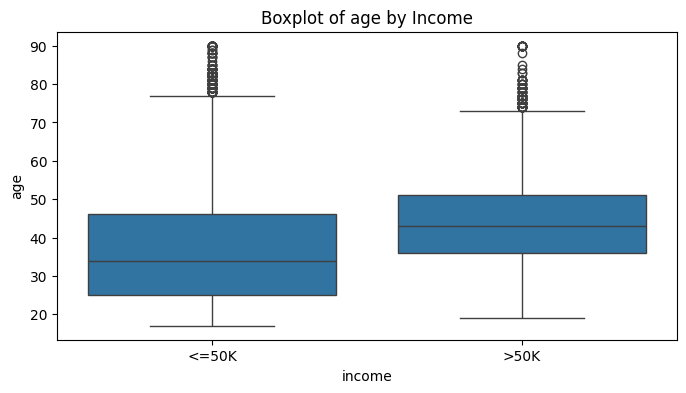

hours-per-week: 13496 outliers (27.63%)


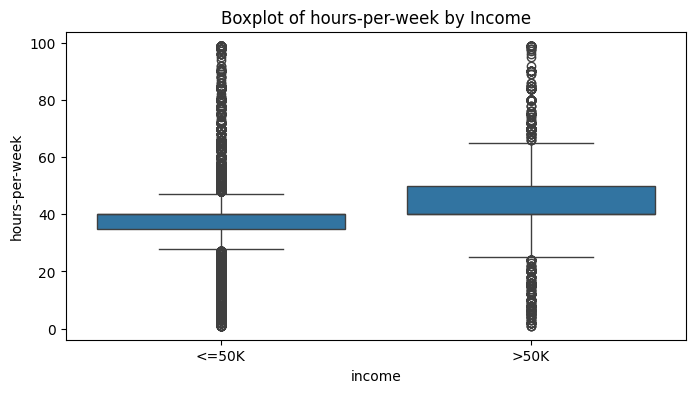

education-num: 1794 outliers (3.67%)


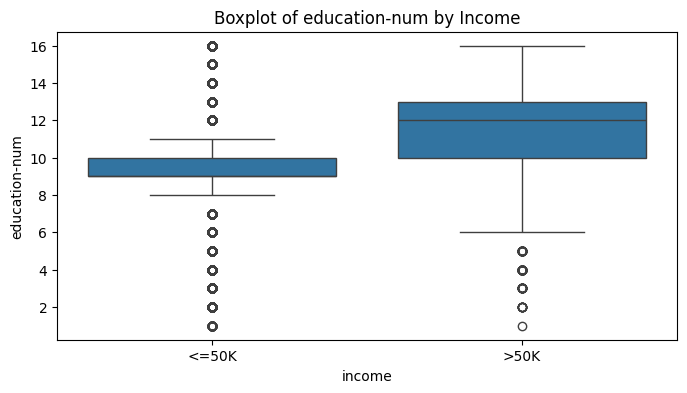

capital-loss: 2282 outliers (4.67%)


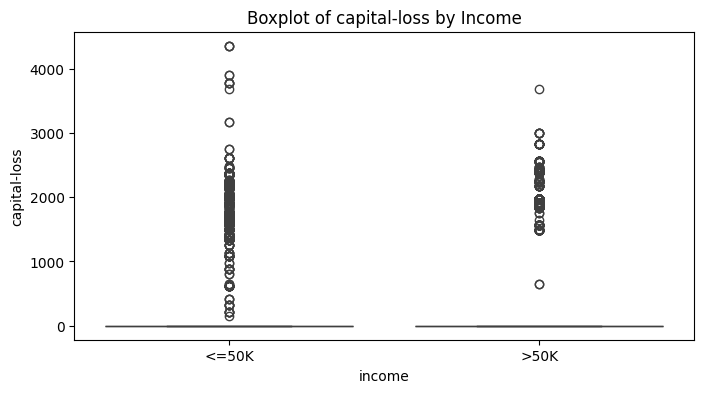

capital-gain: 4035 outliers (8.26%)


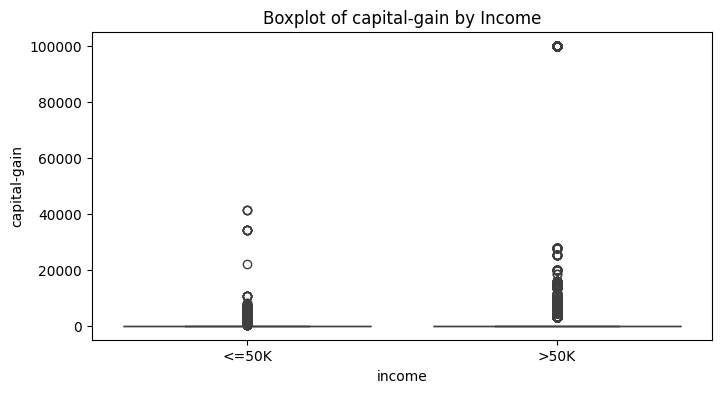

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100

    print(f"{column}: {len(outliers)} outliers ({perc:.2f}%)")

    # Visualizing for the report
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='income', y=column, data=df)
    plt.title(f'Boxplot of {column} by Income')
    plt.savefig(f'graphs/boxplot_{column}.png', dpi=300)
    plt.show()
    plt.close()

    return lower_bound, upper_bound

print("\n--- Outlier Detection ---")
for col in ['age', 'hours-per-week', 'education-num', 'capital-loss', 'capital-gain']:
    handle_outliers(df, col)



Decision: For Census data, we usually CONSERVE outliers
because they represent real valid citizens, not measurement errors. Removing them would reduce the diversity and realism of our dataset.
 These variations can be crucial for distinguishing income brackets.

##Question 2.3 — Traitement des Variables Asymétriques

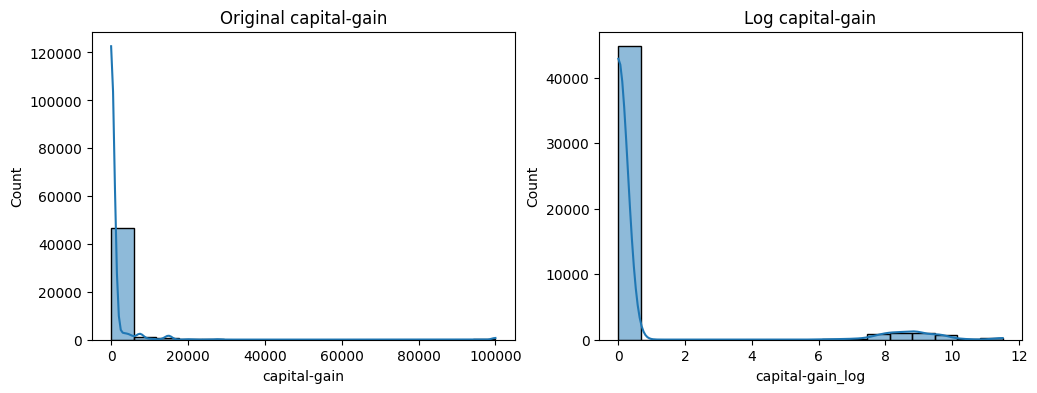

Skewness for capital-gain: Before=11.89, After=3.11


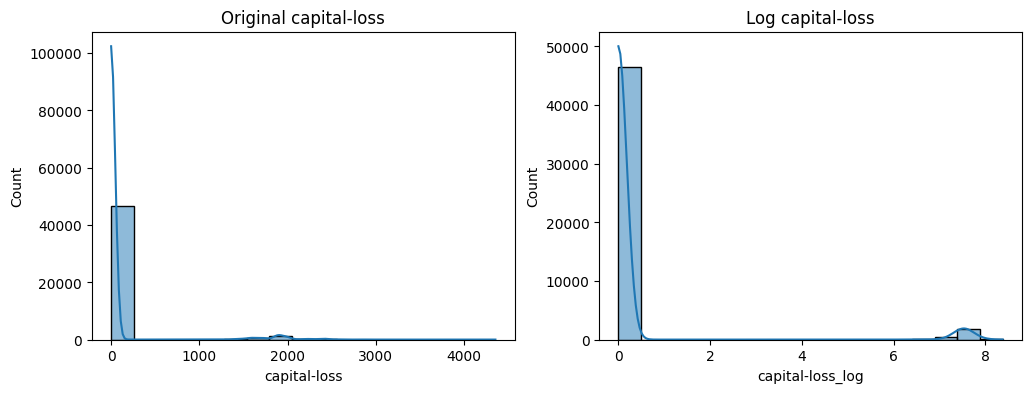

Skewness for capital-loss: Before=4.57, After=4.30


In [70]:
# Identify highly skewed variables
numeric_features = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
skewed_features = df[numeric_features].skew()[abs(df[numeric_features].skew()) > 2].index

for col in skewed_features:
    # Use log1p to handle zeros (common in capital-gain)
    df[f'{col}_log'] = np.log1p(df[col])

    # Comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=ax1).set_title(f'Original {col}')
    sns.histplot(df[f'{col}_log'], kde=True, ax=ax2).set_title(f'Log {col}')
    plt.savefig(f'graphs/skew_transform_{col}.png', dpi=300)
    plt.show()
    plt.close()

    print(f"Skewness for {col}: Before={df[col].skew():.2f}, After={df[f'{col}_log'].skew():.2f}")

##Question 2.4 — Vérification Finale & Sauvegarde

In [71]:
def valider_dataset(df_to_check):
    print('\n--- Final Validation ---')
    print('1. Valeurs manquantes:', df_to_check.isnull().sum().sum())
    print('2. Doublons:', df_to_check.duplicated().sum())
    print('3. Dimensions:', df_to_check.shape)

# Drop any remaining NaNs after replacing '?'
df.dropna(inplace=True)

valider_dataset(df)

# Save the cleaned dataset as required
df.to_csv('adult_cleaned.csv', index=False)
print("\nDataset saved as adult_cleaned.csv")


--- Final Validation ---
1. Valeurs manquantes: 0
2. Doublons: 6017
3. Dimensions: (45222, 16)

Dataset saved as adult_cleaned.csv


#PARTIE 3 : Feature Engineering

##Question 3.1  — Création de Variables de Tendance

          count         mean           std     min  25%  50%  75%      max
income                                                                    
<=50K   34014.0    94.990974    986.785153 -4356.0  0.0  0.0  0.0  41310.0
>50K    11208.0  3798.304604  14681.261319 -3683.0  0.0  0.0  0.0  99999.0


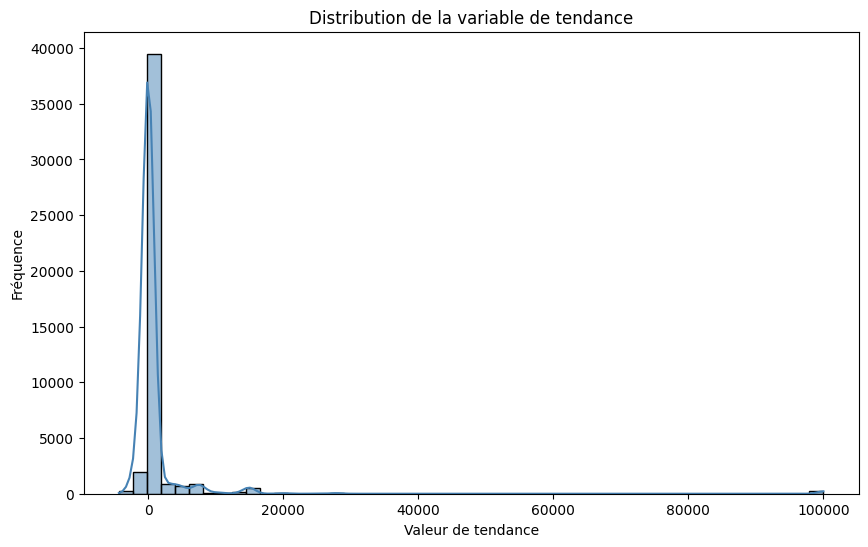

In [72]:
df['net_capital'] = df['capital-gain'] - df['capital-loss']

stats_by_class = df.groupby('income')['net_capital'].describe()
print(stats_by_class)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Histogramme + KDE
sns.histplot(df['net_capital'], bins=50, kde=True, color='steelblue')

plt.title("Distribution de la variable de tendance")
plt.xlabel("Valeur de tendance")
plt.ylabel("Fréquence")
plt.savefig("graphs/trend_var_hist.png")
plt.show()


##Question 3.2    — Création de Ratios / Variables Dérivées



Statistiques pour work_intensity :
             mean    median       std
income                              
<=50K   1.154052  1.111111  0.470930
>50K    1.074857  1.022727  0.368972


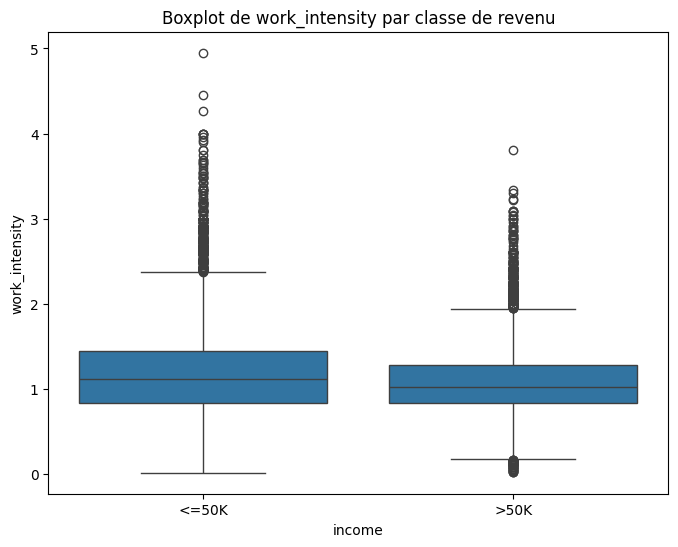

In [73]:
df['work_intensity'] = df['hours-per-week'] / (df['age'] + 1)

ratio =  'work_intensity'

stats = df.groupby('income')[ratio].agg(['mean','median','std'])
print(f"\nStatistiques pour {ratio} :\n", stats)




plt.figure(figsize=(8,6))
sns.boxplot(x='income', y=ratio, data=df)
plt.title(f"Boxplot de {ratio} par classe de revenu")
plt.savefig(f"graphs/boxplot_{ratio}.png")
plt.show()



##Question 3.3  — Agrégations Temporelles / Multi-colonnes


--- Distribution of Financial Activity Count ---
fin_activity_count
0    86.886913
1    13.113087
Name: proportion, dtype: float64


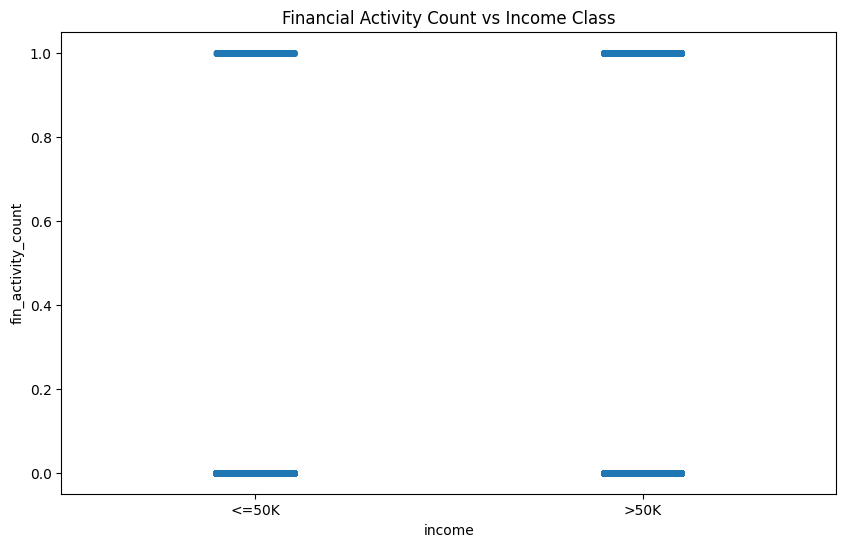

In [74]:
# 1. Count occurrences of financial events (Gain > 0 or Loss > 0)
# This creates a variable where 0 = No activity, 1 = One type, 2 = Both types
cols_fin = ['capital-gain', 'capital-loss']
df['fin_activity_count'] = (df[cols_fin] > 0).sum(axis=1)

# 2. Analyze distribution: Focus on extremes (0 and max)
print("\n--- Distribution of Financial Activity Count ---")
dist = df['fin_activity_count'].value_counts(normalize=True) * 100
print(dist)
# Interpretation: 0 means no investment reported; 2 means both gain and loss (rare)

# 3. Create a 'Mean' variable over similar columns
# Average dollar value of financial flow
df['avg_financial_flow'] = df[cols_fin].mean(axis=1)

# 4. Scatter Plot: Aggregation Variable vs Variable Cible
plt.figure(figsize=(10, 6))
# Using jitter or a boxplot often works better for categorical targets in a scatter context
sns.stripplot(x='income', y='fin_activity_count', data=df, alpha=0.3, jitter=True)
plt.title('Financial Activity Count vs Income Class')
plt.savefig('graphs/scatter_aggregation_target.png', dpi=300)
plt.show()
plt.close()

##Question 3.4 — Transformations Logarithmiques (Tableau)

In [75]:
# Recalculating Skewness for the required table
variables_to_log = ['capital-gain', 'capital-loss', 'age']
comparison_data = []

for var in variables_to_log:
    before = df[var].skew()
    # Apply log transformation (log1p to handle zeros)
    df[f'{var}_log'] = np.log1p(df[var])
    after = df[f'{var}_log'].skew()
    improvement = abs(before) - abs(after)
    comparison_data.append([var, before, after, improvement])

# Displaying the table[cite: 1]
log_table = pd.DataFrame(comparison_data, columns=['Variable', 'Skewness AVANT', 'Skewness APRÈS', 'Amélioration'])
print("\n--- Question 3.4 Table ---")
print(log_table)


--- Question 3.4 Table ---
       Variable  Skewness AVANT  Skewness APRÈS  Amélioration
0  capital-gain       11.789002        3.082386      8.706616
1  capital-loss        4.516304        4.271195      0.245109
2           age        0.532816       -0.138763      0.394053


##Question 3.5 — Bilan du Feature Engineering


Total New Variables Created: 5 (net_capital, work_intensity, fin_activity_count, avg_financial_flow, and various _log versions).

The 3 Most Important Variables:
net_capital: Directly captures wealth accumulation, which is the strongest indicator of high income.  
work_intensity: Normalizes effort relative to life stage (e.g., a student working 40 hours vs. a senior).
fin_activity_count: Acts as a proxy for "Investor" status, which correlates heavily with the >50K class.  

Réflexion Critique:Adding these variables improves the model’s ability to capture non-linear relationships. For instance, capital-gain alone is sparse, but fin_activity_count provides a binary signal that is easier for decision trees to split on. However, there is a risk of Data Leakage if a variable is too closely tied to the target calculation. Furthermore, the log transformation reduces the weight of outliers, which helps linear models but might make interpretation less "human-readable" (e.g., "log-dollars" instead of "dollars"). Final dimensions have increased from 14 to 19 features, providing more "surface area" for the model to learn patterns.

#PARTIE 4 — Analyse Exploratoire Avancée (EDA)

##Question 4.1  — Matrice de Corrélation

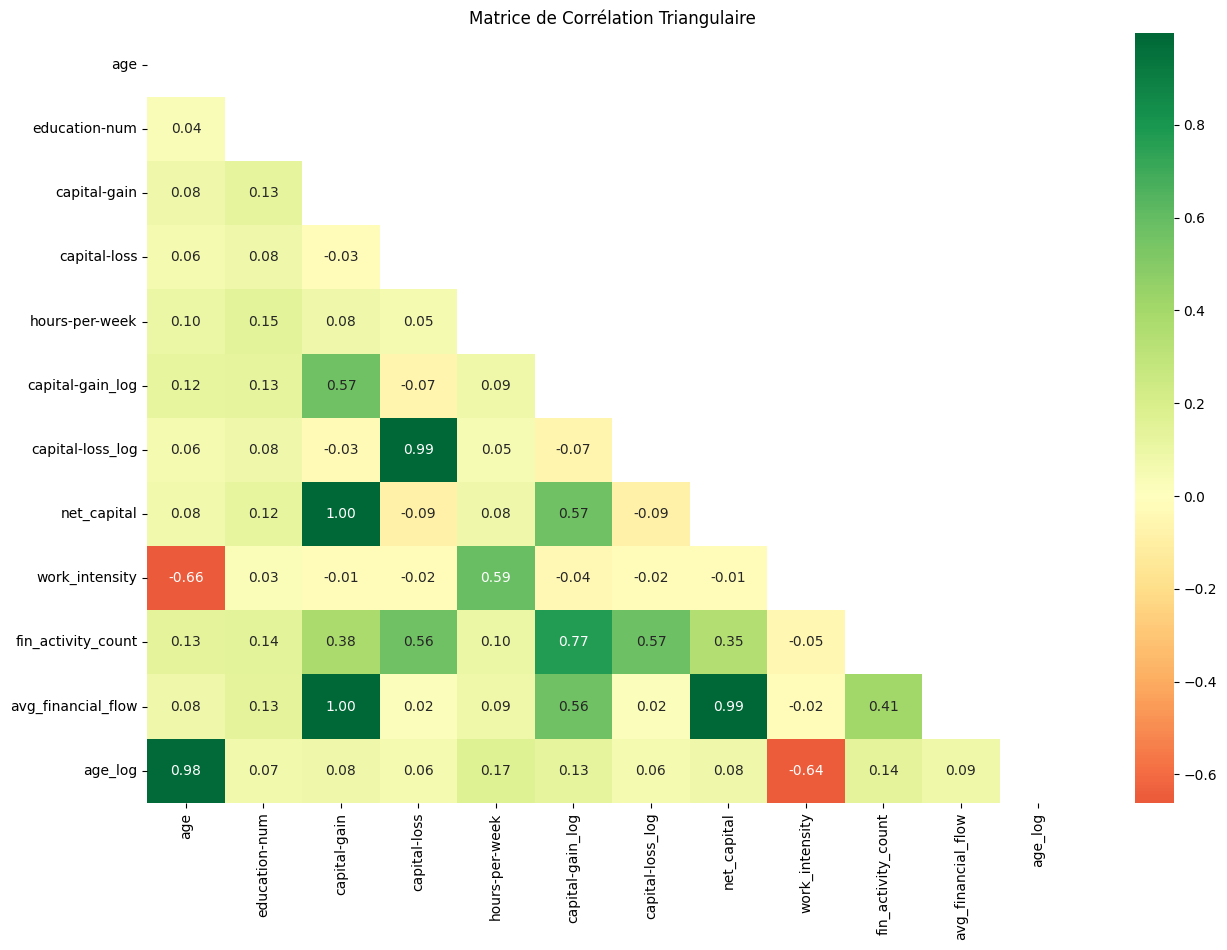


--- Paires avec r > 0.7 ---
                   Var1                Var2         r
11                  age             age_log  0.981748
31         capital-gain         net_capital  0.998554
34         capital-gain  avg_financial_flow  0.998544
42         capital-loss    capital-loss_log  0.986934
69     capital-gain_log  fin_activity_count  0.773073
75     capital-loss_log        capital-loss  0.986934
86          net_capital        capital-gain  0.998554
94          net_capital  avg_financial_flow  0.994202
113  fin_activity_count    capital-gain_log  0.773073
122  avg_financial_flow        capital-gain  0.998544
127  avg_financial_flow         net_capital  0.994202
132             age_log                 age  0.981748


In [76]:

# Calculate correlation for numerical variables
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Create a triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matrice de Corrélation Triangulaire')
plt.savefig('graphs/heatmap_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify high correlations (|r| > 0.7)
high_corr = corr_matrix.stack().reset_index()
high_corr.columns = ['Var1', 'Var2', 'r']
high_corr = high_corr[(abs(high_corr['r']) > 0.7) & (high_corr['Var1'] != high_corr['Var2'])]
print("\n--- Paires avec r > 0.7 ---")
print(high_corr)

In [77]:
# variable a supprimer
deleted_variables = ['age_log', 'net_capital', 'avg_financial_flow','capital-loss_log']

##Question 4.2 — Corrélations avec la Variable Cible

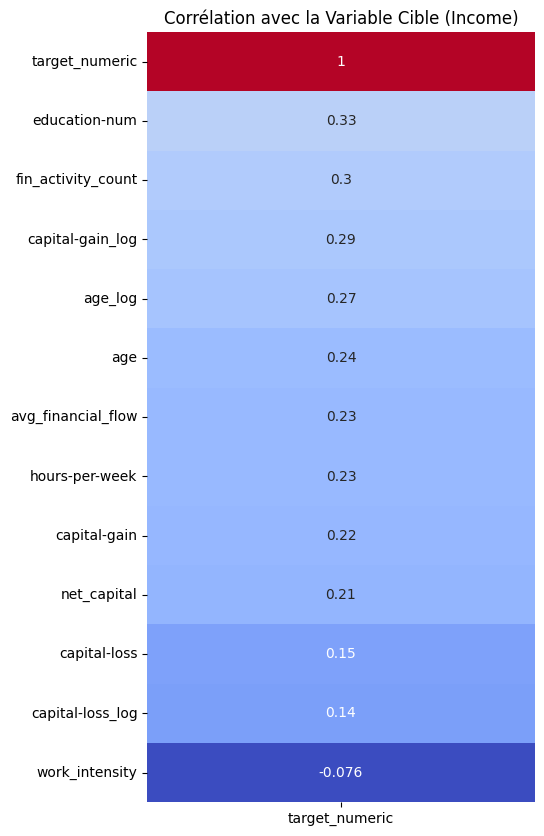


--- TOP 10 Variables les plus corrélées ---
target_numeric        1.000000
education-num         0.332800
fin_activity_count    0.303963
capital-gain_log      0.287740
age_log               0.269129
age                   0.237040
avg_financial_flow    0.229119
hours-per-week        0.227199
capital-gain          0.221034
net_capital           0.212337
capital-loss          0.148687
Name: target_numeric, dtype: float64


In [78]:
# Temporary encoding for correlation
df['target_numeric'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Correlation with target
target_corr = df.select_dtypes(include=[np.number]).corr()['target_numeric'].sort_values(ascending=False)


# Vertical Heatmap
plt.figure(figsize=(5, 10))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Corrélation avec la Variable Cible (Income)')
plt.savefig('graphs/target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- TOP 10 Variables les plus corrélées ---")
print(target_corr.head(11)) # 11 because target-target is always 1.0

##Question 4.3  — Distributions Univariées

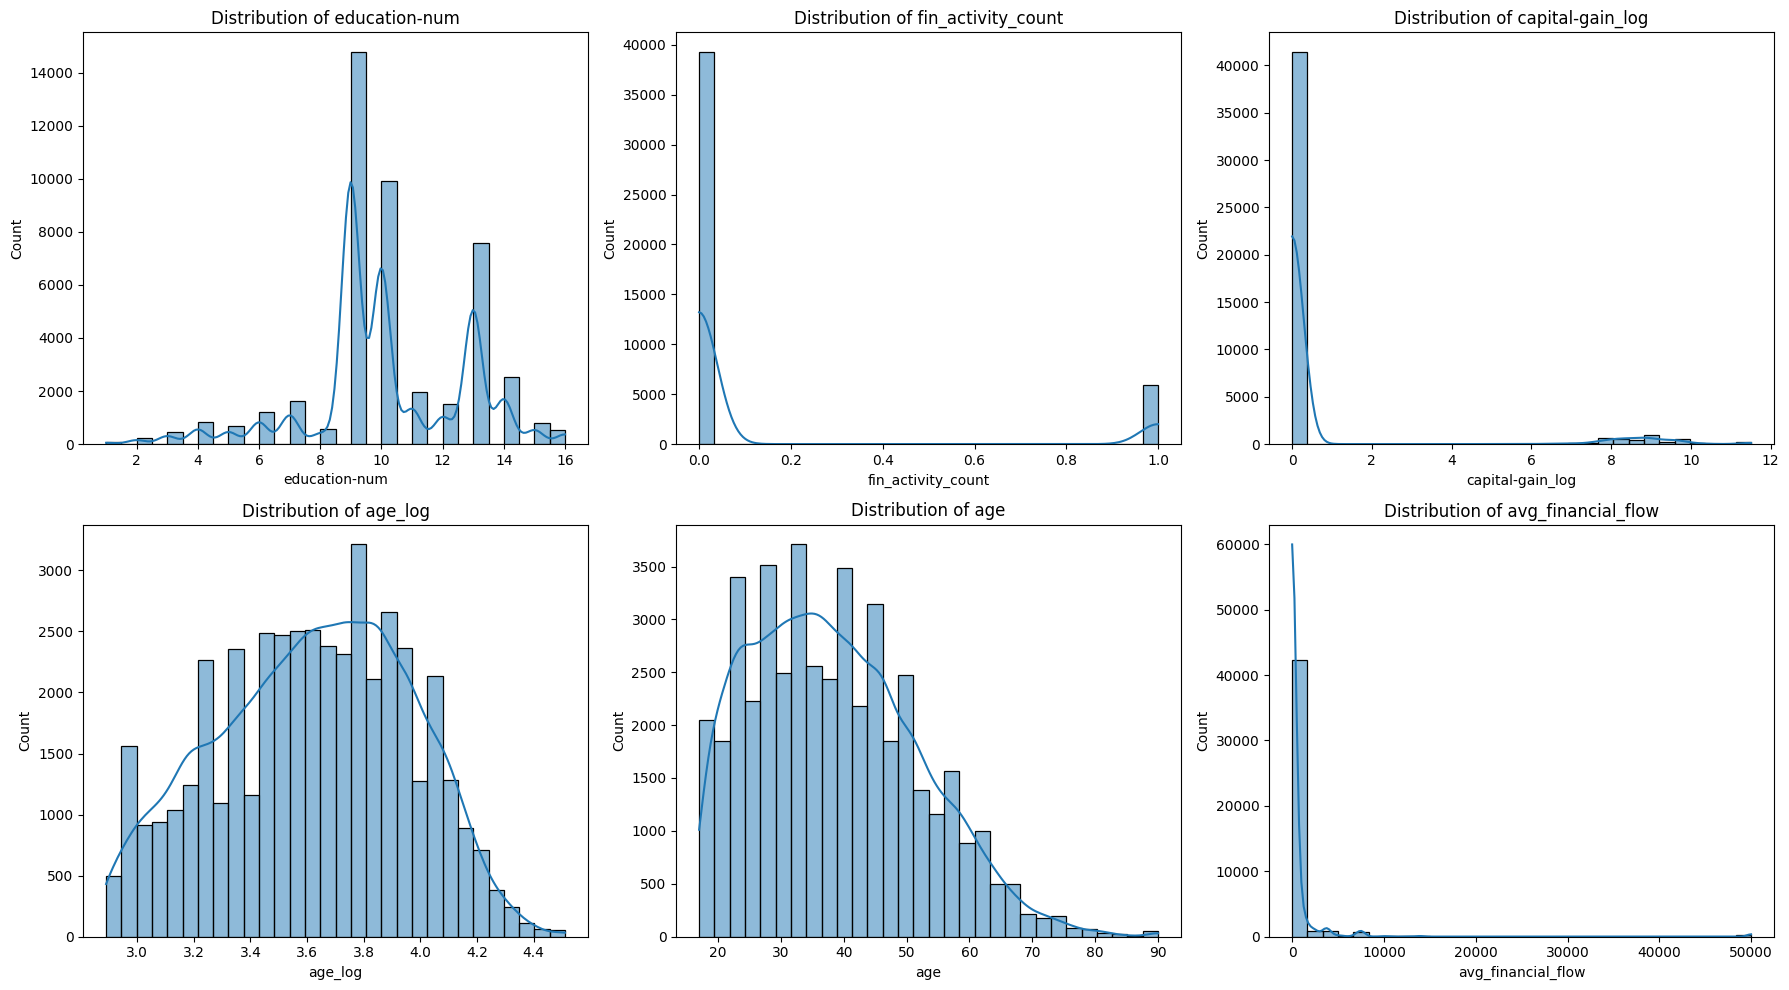

In [79]:
# Selecting top 6 variables based on correlation results
top_features = target_corr.index[1:7].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('graphs/distributions_univariees.png', dpi=300)
plt.show()

# Recapitulative table for your report[cite: 1]
# Note: In your report, describe if they are "Right-skewed", "Bimodal", or "Normal"[cite: 1].

##Question 4.4 — Analyse Bivariée

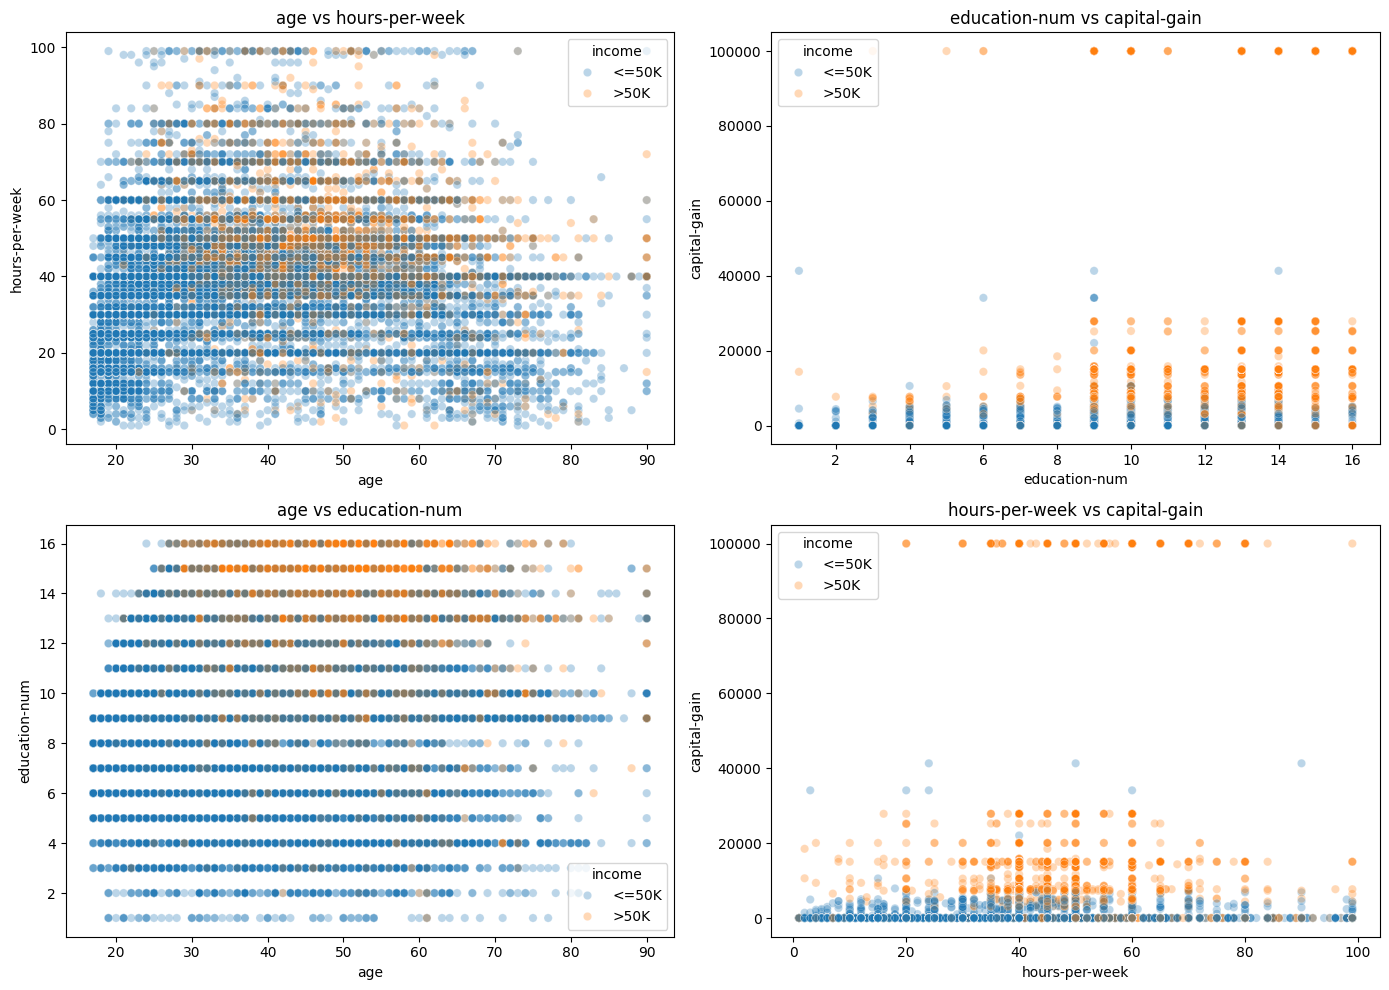

In [80]:
# 1. Four Scatter plots with alpha=0.3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatter_pairs = [('age', 'hours-per-week'), ('education-num', 'capital-gain'),
                 ('age', 'education-num'), ('hours-per-week', 'capital-gain')]

for i, (x_col, y_col) in enumerate(scatter_pairs):
    row, col = divmod(i, 2)
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='income', alpha=0.3, ax=axes[row, col])
    axes[row, col].set_title(f'{x_col} vs {y_col}')

plt.tight_layout()
plt.savefig('graphs/analyse_bivariee.png', dpi=300)
plt.show()



#PARTIE 5 — Préparation pour le Machine Learning

##Question 5.1 — Sélection des Features

In [81]:
selected_features = [
    'age', 'education-num', 'hours-per-week',
    'net_capital', 'work_intensity', 'fin_activity_count',
    'workclass',  'occupation', 'relationship', 'race', 'sex'
]

df['sex'].replace({'Male':1, 'Female':0}, inplace=True)

X = df[selected_features]
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# One-Hot Encoding for categorical variables to prepare for Scikit-Learn
X = pd.get_dummies(X, drop_first=False)

print(f"Final feature count after encoding: {X.shape[1]}")






Final feature count after encoding: 37


/tmp/ipykernel_2277/2004389780.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].replace({'Male':1, 'Female':0}, inplace=True)
/tmp/ipykernel_2277/2004389780.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'].replace({'Male':1, 'Female':0}, inplace=True)


##Question 5.2 — Split Train/Test Stratifié

In [82]:
from sklearn.model_selection import train_test_split

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Train set: {X_train.shape[0]} lines")
print(f"Test set: {X_test.shape[0]} lines")
print(f"Train Class 1 percentage: {(y_train.sum() / len(y_train) * 100):.2f}%")
print(f"Test Class 1 percentage: {(y_test.sum() / len(y_test) * 100):.2f}%")

# Why use stratify=y?
# It ensures that the minority class (>50K) is represented proportionally in both sets,


Train set: 36177 lines
Test set: 9045 lines
Train Class 1 percentage: 24.78%
Test Class 1 percentage: 24.79%


##Question 5.3 — Normalisation

Mean of scaled train: 0.0000
Std of scaled train: 1.0000


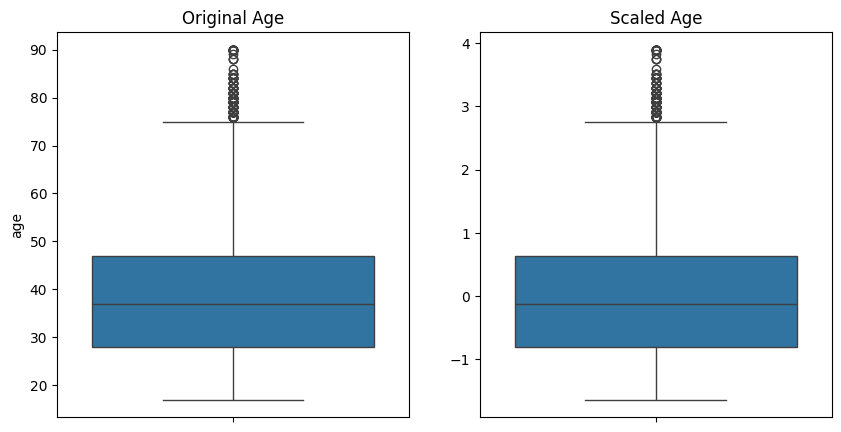

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on train, transform only on test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validation of normalization (Mean ~ 0, Std ~ 1)
print(f"Mean of scaled train: {X_train_scaled.mean():.4f}")
print(f"Std of scaled train: {X_train_scaled.std():.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train.iloc[:, 0]).set_title('Original Age')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[:, 0]).set_title('Scaled Age')
plt.savefig('graphs/normalization_check.png', dpi=300)
plt.show()
plt.close()

##Question 5.4 — Gestion du Déséquilibre (SMOTE)

In [84]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training set
smote = SMOTE(random_state=42, sampling_strategy=0.8) # Minority will be 80% of majority size
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE Class 1 count: {y_train.sum()}")
print(f"After SMOTE Class 1 count: {y_train_resampled.sum()}")

# Why not apply SMOTE to the test set?
# The test set must remain 'unseen' and realistic. If we generate synthetic data
# in the test set, we would be evaluating the model on fake samples.

Before SMOTE Class 1 count: 8966
After SMOTE Class 1 count: 21768


#PARTIE 6 — Sélection Avancée des Features

##Question 6.1  — Méthodes Filtre — Importance Statistique

--- TOP 5 Pearson Correlations ---
relationship_Husband    0.404267
education-num           0.332984
fin_activity_count      0.305653
age                     0.236067
hours-per-week          0.226609
dtype: float64
--- TOP 5 spearman Correlations ---
relationship_Husband    0.404267
education-num           0.332984
fin_activity_count      0.305653
age                     0.236067
hours-per-week          0.226609
dtype: float64

--- TOP 5 ANOVA F-Scores ---
                 Feature      F-Score  P-Value
27  relationship_Husband  7067.148446      0.0
1          education-num  4511.225914      0.0
5     fin_activity_count  3727.878465      0.0
0                    age  2134.913059      0.0
2         hours-per-week  1958.209935      0.0


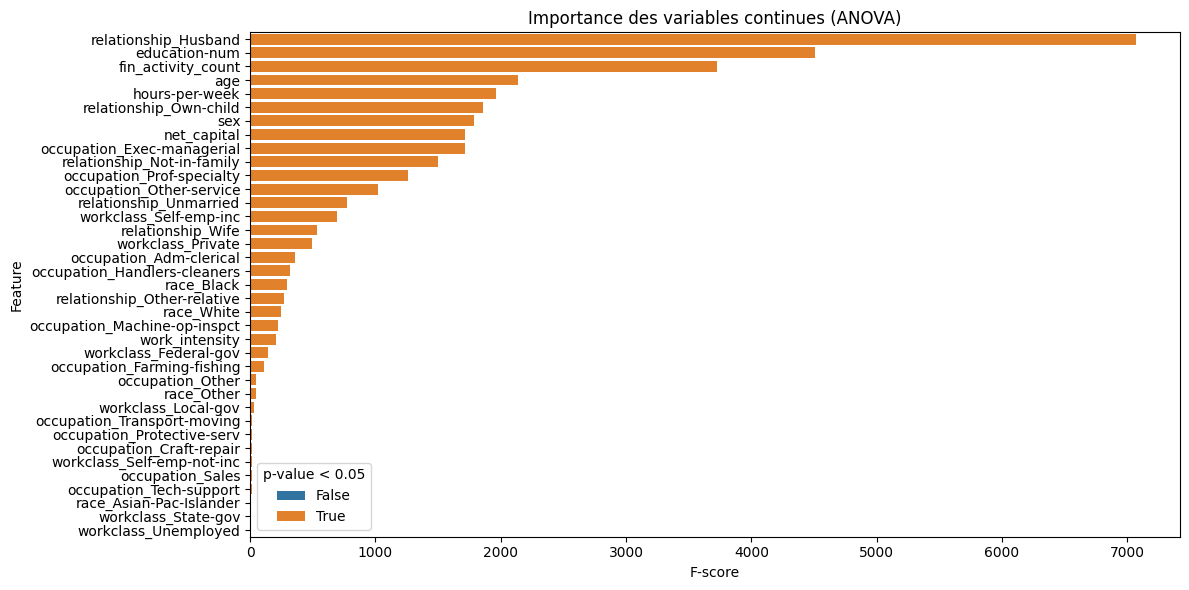

In [85]:
from sklearn.feature_selection import f_classif,chi2

# 1. Pearson Correlation (Linear relationship with Target)
# We use the scaled training data converted back to a DataFrame for labeling
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
pearson_corr = X_train_df.corrwith(pd.Series(y_train.values, name='target'),method='pearson').sort_values(ascending=False)
spearman_corr = X_train_df.corrwith(pd.Series(y_train.values, name='target'),method='pearson').sort_values(ascending=False)
print("--- TOP 5 Pearson Correlations ---")
print(pearson_corr.head(5))

print("--- TOP 5 spearman Correlations ---")
print(spearman_corr.head(5))

# 2. ANOVA F-test (Statistical significance)
f_scores, p_values = f_classif(X_train_scaled, y_train)
anova_df = pd.DataFrame({'Feature': X.columns, 'F-Score': f_scores, 'P-Value': p_values})
anova_df = anova_df.sort_values(by='F-Score', ascending=False)


print("\n--- TOP 5 ANOVA F-Scores ---")
print(anova_df.head(5))




plt.figure(figsize=(12,6))
sns.barplot(x='F-Score', y='Feature', data=anova_df,
            hue=(anova_df['P-Value'] < 0.05))
plt.title("Importance des variables continues (ANOVA)")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.legend(title="p-value < 0.05")
plt.tight_layout()
plt.savefig("graphs/anova_importance.png")
plt.show()

significant_anova = anova_df[anova_df['P-Value'] < 0.05]['Feature']

##Question 6.2 — Méthodes Wrapper (RFE)

In [86]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Base estimator
rf = RandomForestClassifier(n_estimators=50, random_state=42)

# Try different numbers of features
n_features_list = [5, 8, 10, 12]
f1_scores = []

for n in n_features_list:
    rfe = RFE(estimator=rf, n_features_to_select=n)
    rfe.fit(X_train_scaled, y_train)

    # Selected features
    selected_features_names = X.columns[rfe.support_].tolist()
    print(f"\nFeatures selected with n={n}: {selected_features_names}")

    # Train model on selected features
    # Need to select columns from the scaled arrays using the boolean mask or indices
    rf.fit(X_train_scaled[:, rfe.support_], y_train)
    y_pred = rf.predict(X_test_scaled[:, rfe.support_])

    score = f1_score(y_test, y_pred)
    f1_scores.append(score)
    print(f"F1-score with {n} features: {score:.4f}")


Features selected with n=5: ['age', 'education-num', 'net_capital', 'work_intensity', 'relationship_Husband']
F1-score with 5 features: 0.6310

Features selected with n=8: ['age', 'education-num', 'hours-per-week', 'net_capital', 'work_intensity', 'fin_activity_count', 'relationship_Husband', 'relationship_Wife']
F1-score with 8 features: 0.6419

Features selected with n=10: ['age', 'education-num', 'hours-per-week', 'net_capital', 'work_intensity', 'fin_activity_count', 'occupation_Exec-managerial', 'occupation_Prof-specialty', 'relationship_Husband', 'relationship_Wife']
F1-score with 10 features: 0.6468

Features selected with n=12: ['age', 'education-num', 'hours-per-week', 'net_capital', 'work_intensity', 'fin_activity_count', 'sex', 'occupation_Exec-managerial', 'occupation_Prof-specialty', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Wife']
F1-score with 12 features: 0.6422


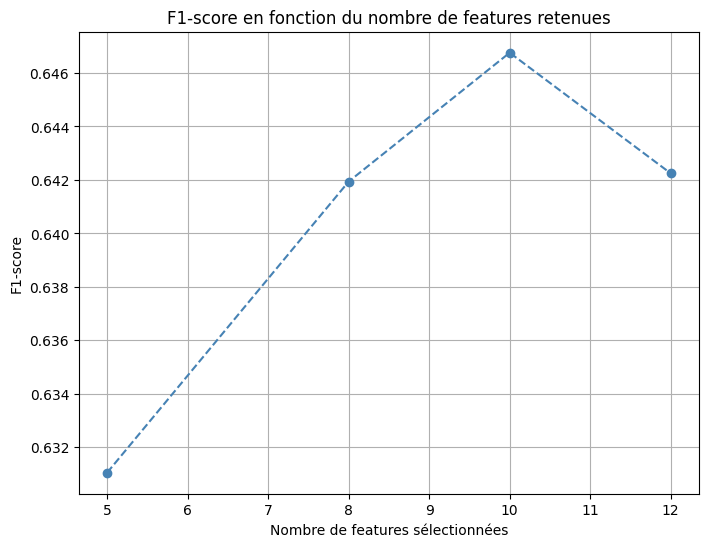

In [87]:

plt.figure(figsize=(8,6))
plt.plot(n_features_list, f1_scores, marker='o', linestyle='--', color='steelblue')
plt.title("F1-score en fonction du nombre de features retenues")
plt.xlabel("Nombre de features sélectionnées")
plt.ylabel("F1-score")
plt.grid(True)
plt.savefig("graphs/rfe_f1_scores.png")
plt.show()


In [88]:
#le nombre optimal est 12 :
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Initialize estimator
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42)

# Select top 12 features
rfe = RFE(estimator=rf_selector, n_features_to_select=12, step=1)
rfe.fit(X_train_scaled, y_train)

rfe_features = X.columns[rfe.support_].tolist()
print("\n--- RFE Selected Features (Top 12) ---")
print(rfe_features)


--- RFE Selected Features (Top 12) ---
['age', 'education-num', 'hours-per-week', 'net_capital', 'work_intensity', 'fin_activity_count', 'sex', 'occupation_Exec-managerial', 'occupation_Prof-specialty', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Wife']


##Question 6.3  — Méthodes Embedded — Importance par Modèle

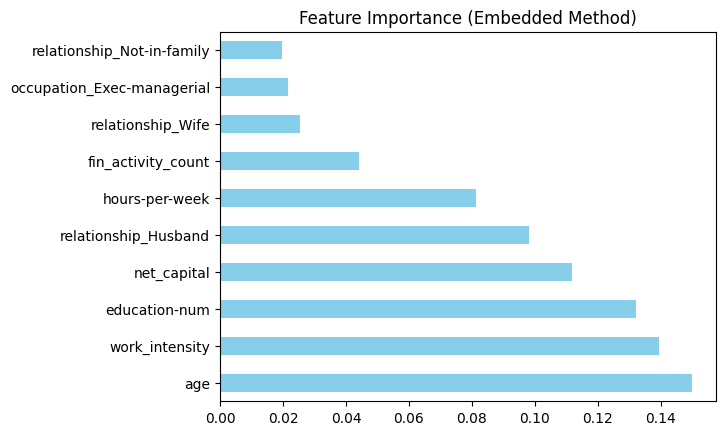

Features retenues (importance > moyenne): ['age', 'education-num', 'hours-per-week', 'net_capital', 'work_intensity', 'fin_activity_count', 'sex', 'occupation_Exec-managerial', 'occupation_Prof-specialty', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Wife']
Top-5 features RandomForest: ['age', 'work_intensity', 'education-num', 'net_capital', 'relationship_Husband']
Top-5 features GradientBoosting: ['relationship_Husband', 'net_capital', 'education-num', 'relationship_Wife', 'age']


In [89]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier

# Training the model to get importances
rf_selector.fit(X_train_scaled, y_train)
importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualization for the report
importances.head(10).plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Embedded Method)')
plt.savefig('graphs/embedded_importance.png', dpi=300)
plt.show()


selector = SelectFromModel(rf, threshold='mean')
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

selected_features = X.columns[rfe.support_].tolist()
print("Features retenues (importance > moyenne):", selected_features)



gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

gb_importances = pd.Series(gb.feature_importances_, index=X.columns)
gb_top5 = gb_importances.sort_values(ascending=False).head(5).index.tolist()

rf_top5 = importances.head(5).index.tolist()

print("Top-5 features RandomForest:", rf_top5)
print("Top-5 features GradientBoosting:", gb_top5)



##Question 6.4  — Analyse par Permutation

In [90]:
from sklearn.inspection import permutation_importance

# Calcul des importances par permutation
result = permutation_importance(rf_selector, X_test_scaled, y_test,
                                n_repeats=10, random_state=42)

perm_imp = pd.DataFrame({
    'feature': X.columns,
    'mean': result.importances_mean,
    'std': result.importances_std
}).sort_values('mean', ascending=False)

print(perm_imp.head(20))


                         feature      mean       std
3                    net_capital  0.035677  0.001510
1                  education-num  0.028303  0.001393
27          relationship_Husband  0.026633  0.002421
5             fin_activity_count  0.009751  0.001534
0                            age  0.006932  0.002210
32             relationship_Wife  0.006169  0.000430
16    occupation_Exec-managerial  0.005572  0.001134
2                 hours-per-week  0.004013  0.001162
21      occupation_Other-service  0.002211  0.001208
28    relationship_Not-in-family  0.002211  0.001143
6                            sex  0.001625  0.000914
22     occupation_Prof-specialty  0.001349  0.001401
19  occupation_Machine-op-inspct  0.000951  0.000634
7          workclass_Federal-gov  0.000851  0.000380
23    occupation_Protective-serv  0.000730  0.000193
18  occupation_Handlers-cleaners  0.000674  0.000273
11    workclass_Self-emp-not-inc  0.000652  0.000751
33       race_Asian-Pac-Islander  0.000365  0.

/tmp/ipykernel_2277/2552137604.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances.T, labels=X.columns)


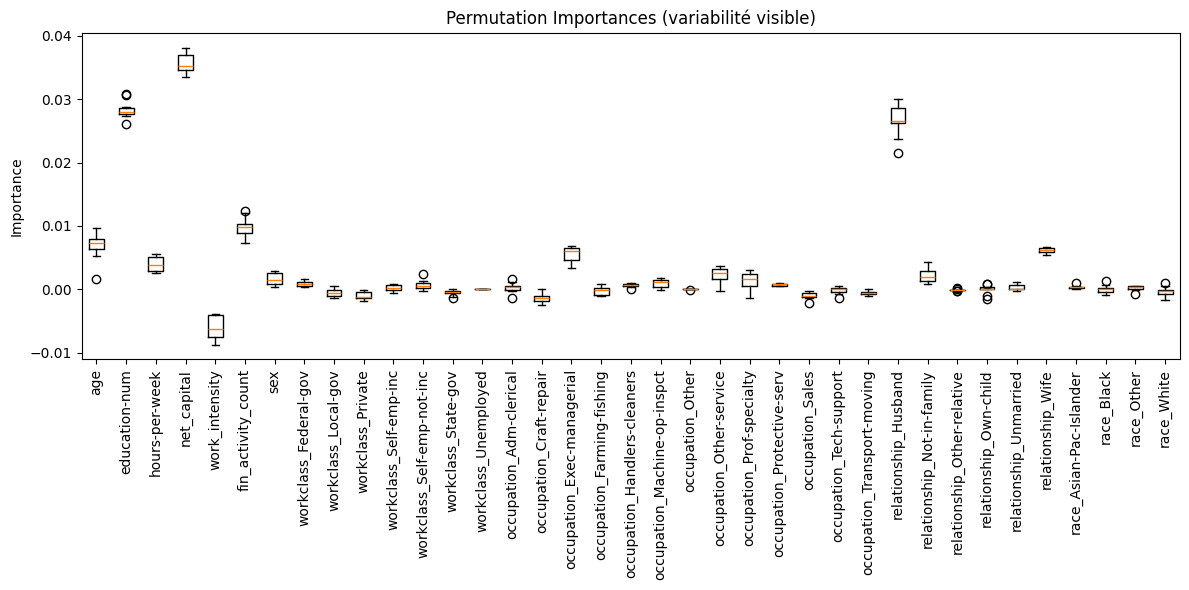

In [91]:

plt.figure(figsize=(12,6))
plt.boxplot(result.importances.T, labels=X.columns)
plt.xticks(rotation=90)
plt.title("Permutation Importances (variabilité visible)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("graphs/permutation_importances_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [92]:
rf_importances = importances

comparison = pd.DataFrame({
    'RF_importance': rf_importances,
    'Permutation_mean': perm_imp.set_index('feature')['mean']
}).sort_values('Permutation_mean', ascending=False)

print(comparison.head(37))


                              RF_importance  Permutation_mean
net_capital                        0.111649          0.035677
education-num                      0.131963          0.028303
relationship_Husband               0.097997          0.026633
fin_activity_count                 0.044254          0.009751
age                                0.149970          0.006932
relationship_Wife                  0.025347          0.006169
occupation_Exec-managerial         0.021508          0.005572
hours-per-week                     0.081148          0.004013
occupation_Other-service           0.007642          0.002211
relationship_Not-in-family         0.019709          0.002211
sex                                0.018969          0.001625
occupation_Prof-specialty          0.016689          0.001349
occupation_Machine-op-inspct       0.004693          0.000951
workclass_Federal-gov              0.005539          0.000851
occupation_Protective-serv         0.003326          0.000730
occupati

##Question 6.5  — Synthèse — Jeu de Features Final

In [93]:
X_final_train = X_train_resampled[:, rfe.support_]
X_final_test = X_test_scaled[:, rfe.support_]

# Important: y_final_train must match the resampled X
y_final_train = y_train_resampled
y_final_test = y_test

#PARTIE 7 — Modélisation, Comparaison & Prévision

##Question 7.1    — Entraînement des Modèles de Base

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import time
from sklearn.metrics import f1_score
import joblib


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
}



results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_final_train, y_train_resampled)   # entraînement
    end = time.time()

    # Prédictions sur le test
    y_pred = model.predict(X_final_test)
    f1 = f1_score(y_test, y_pred)

    # Sauvegarde du modèle
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_model.pkl")

    # Résultats
    results[name] = {
        'train_time': end - start,
        'f1_score': f1
    }

# Afficher les résultats
for name, res in results.items():
    print(f"{name}: F1={res['f1_score']:.4f}, Temps={res['train_time']:.2f} sec")


Logistic Regression: F1=0.6752, Temps=0.35 sec
Decision Tree: F1=0.6175, Temps=0.43 sec
Random Forest: F1=0.6474, Temps=8.72 sec
Gradient Boosting: F1=0.6966, Temps=6.60 sec
SVM: F1=0.6749, Temps=475.07 sec


##Question 7.2  — Évaluation et Comparaison des Performances

In [95]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

results = {}

for name, model in models.items():
    y_pred = model.predict(X_final_test)
    y_prob = model.predict_proba(X_final_test)[:, 1]  # probabilité classe positive

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }

# Convertir en DataFrame pour comparaison
results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Logistic Regression  0.815589   0.599171  0.773417  0.675234  0.894452
Decision Tree        0.819458   0.650222  0.587868  0.617475  0.807177
Random Forest        0.829851   0.665568  0.630241  0.647423  0.883852
Gradient Boosting    0.834052   0.636969  0.768510  0.696584  0.909930
SVM                  0.802875   0.570768  0.825602  0.674932  0.881585


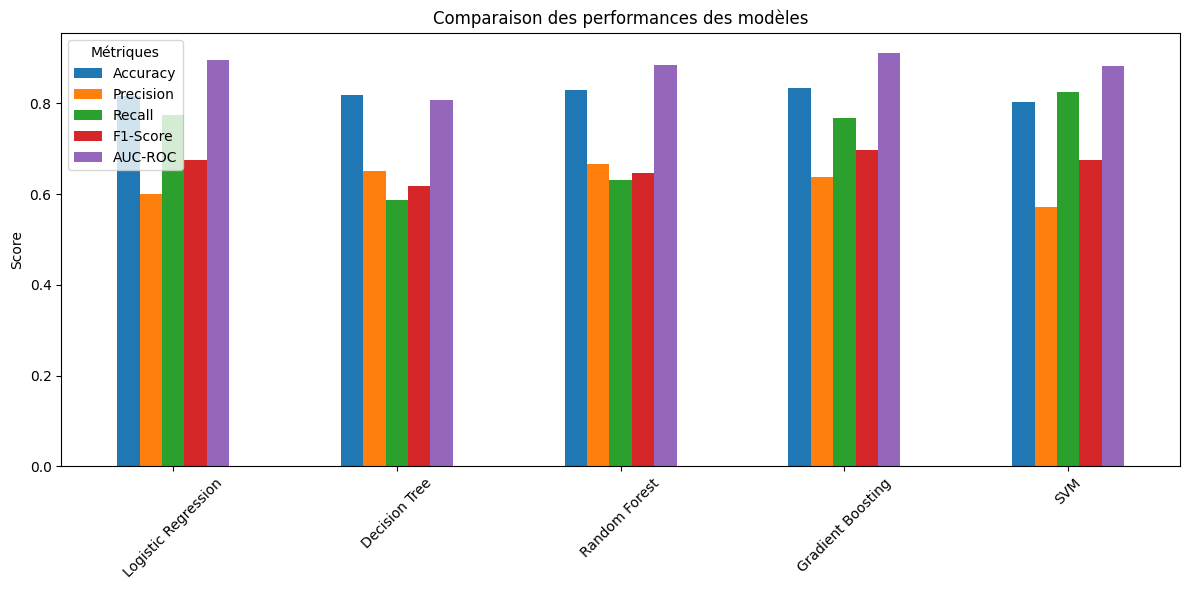

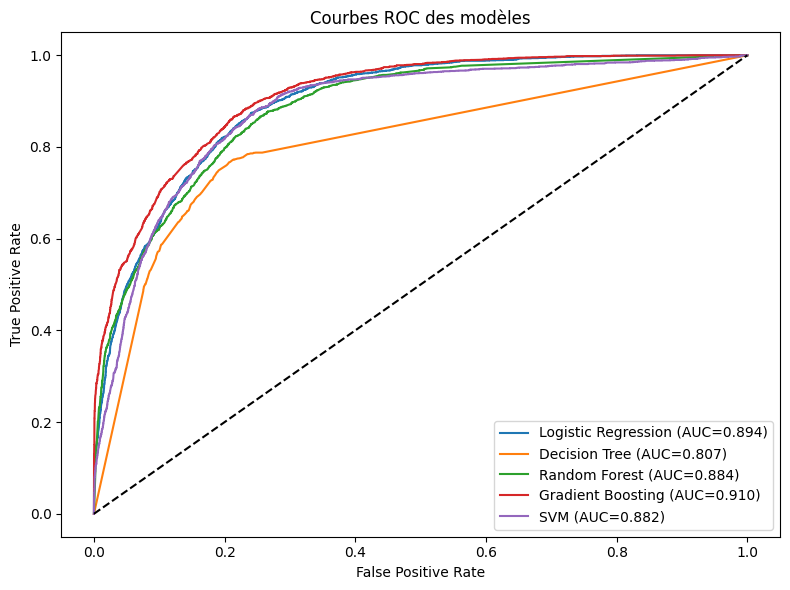

In [97]:
from sklearn.metrics import roc_curve

results_df.plot(kind='bar', figsize=(12,6))
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Métriques")
plt.tight_layout()
plt.savefig("graphs/model_performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_final_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={results[name]["AUC-ROC"]:.3f})')

plt.plot([0,1],[0,1],'k--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC des modèles")
plt.legend()
plt.tight_layout()
plt.savefig('graphs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


##Question 7.3  — Matrices de Confusion et Analyse des Erreurs

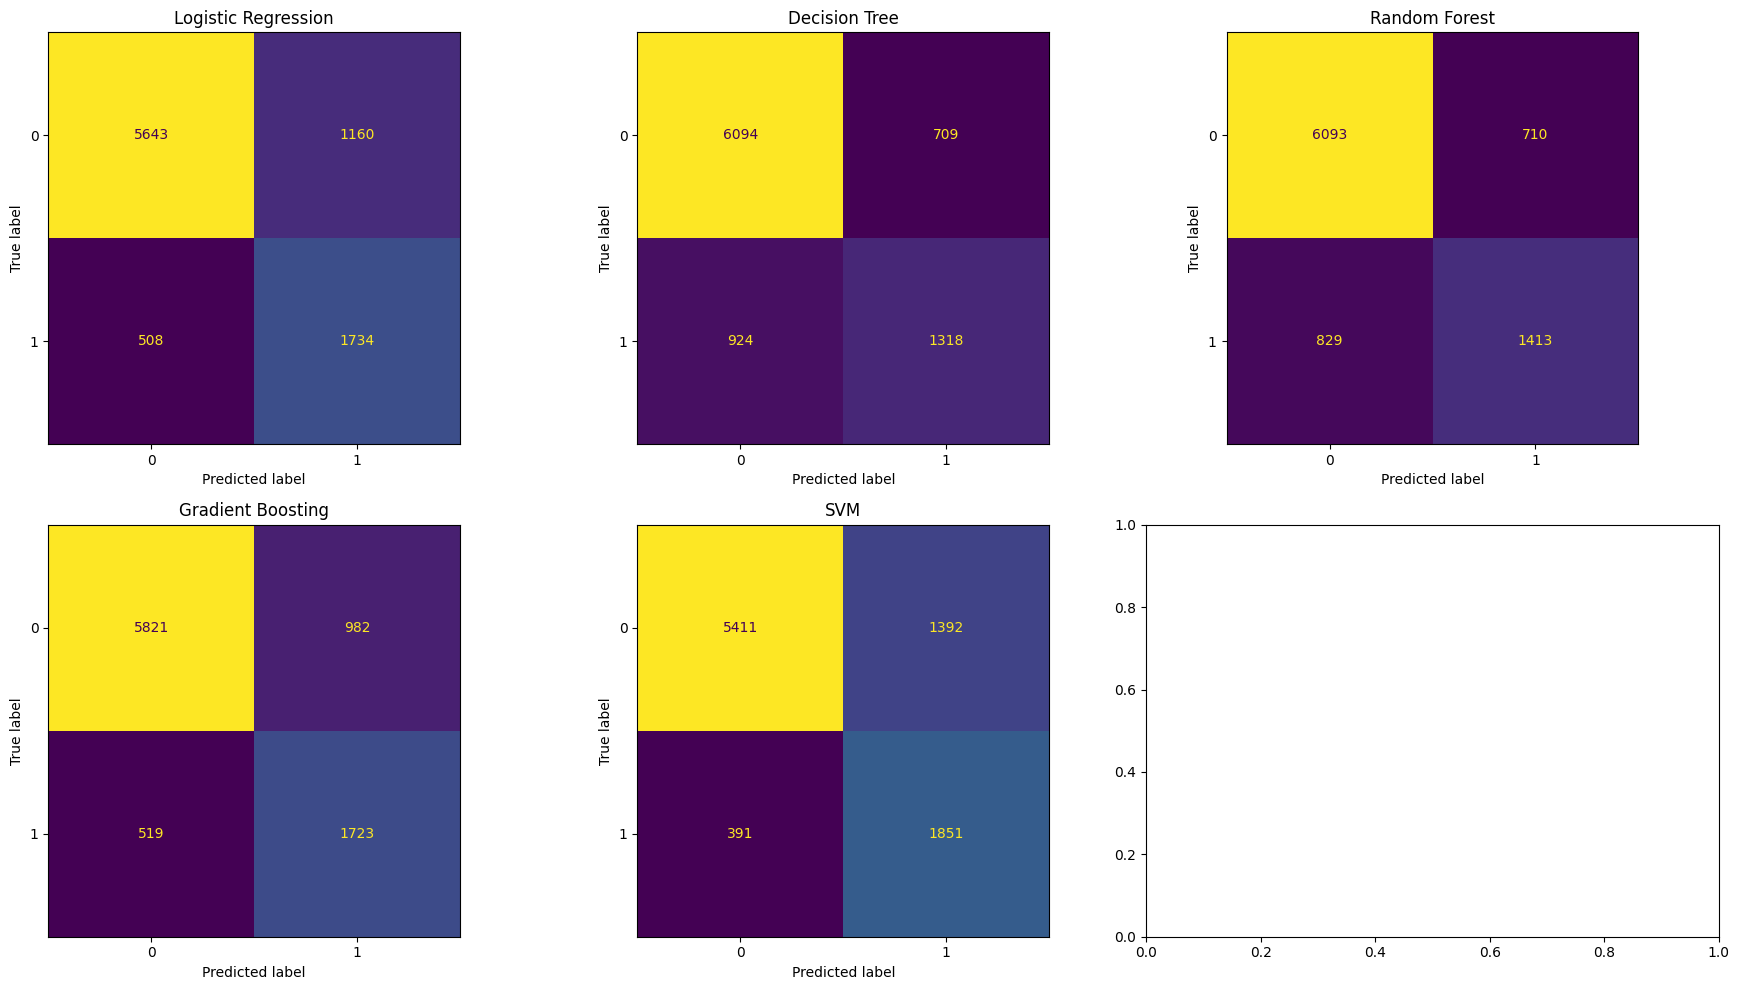

Indices systématiquement mal classés: [  19   35   64  106  119  129  133  144  154  173  189  203  206  208
  230  236  302  321  332  337  339  359  373  377  391  397  427  432
  436  437  461  477  485  499  512  535  550  552  563  572  586  588
  597  598  610  629  637  652  654  682  685  691  695  700  706  713
  718  750  761  793  798  800  847  871  875  879  884  905  914  917
  969  996 1027 1041 1050 1055 1058 1076 1093 1094 1122 1196 1218 1229
 1243 1248 1249 1259 1272 1287 1304 1305 1327 1340 1363 1370 1403 1420
 1432 1439 1444 1450 1451 1474 1498 1500 1542 1576 1579 1582 1594 1604
 1609 1615 1626 1658 1694 1706 1708 1714 1732 1734 1744 1749 1758 1773
 1794 1803 1810 1812 1828 1830 1841 1863 1870 1875 1880 1892 1897 1910
 1931 1937 1960 1966 1980 1992 1999 2017 2022 2025 2046 2047 2069 2081
 2140 2168 2189 2196 2198 2216 2267 2270 2282 2303 2313 2328 2334 2336
 2346 2348 2349 2359 2366 2381 2395 2410 2414 2419 2440 2483 2501 2512
 2517 2523 2552 2553 2583 2672 2682 268

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay



fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (name, model) in zip(axes.flat, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_final_test, y_test, ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig('graphs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


misclassified_all = np.ones(len(y_test), dtype=bool)

for name, model in models.items():
    y_pred = model.predict(X_final_test)
    misclassified = (y_pred != y_test)
    misclassified_all &= misclassified

indices_misclassified = np.where(misclassified_all)[0]
print("Indices systématiquement mal classés:", indices_misclassified)
# Use rfe_features for column names, as X_final_test was created using rfe.support_
print("Échantillons concernés:\n", pd.DataFrame(X_final_test, columns=rfe_features).iloc[indices_misclassified])


##Question 7.4  — Optimisation — GridSearchCV & Cross-Validation

In [100]:
"""

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

cv_scores_rf = cross_val_score(LogisticRegression(random_state=42),
                               X_final_train, y_train_resampled,
                               cv=5, scoring='f1')
print(f'RandomForest CV F1 : {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}')

# Exemple avec GradientBoosting
cv_scores_gb = cross_val_score(GradientBoostingClassifier(random_state=42),
                               X_final_train, y_train_resampled,
                               cv=5, scoring='f1')
print(f'GradientBoosting CV F1 : {cv_scores_gb.mean():.4f} +/- {cv_scores_gb.std():.4f}')



param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1',
                           n_jobs=-1, verbose=1)

grid_search.fit(X_final_train, y_train_resampled)

print('Meilleurs params:', grid_search.best_params_)
best_rf = grid_search.best_estimator_



# Avant tuning
rf_default = GradientBoostingClassifier(random_state=42)
rf_default.fit(X_final_train, y_train_resampled)
y_pred_default = rf_default.predict(X_final_test)
y_prob_default = rf_default.predict_proba(X_final_test)[:,1]

print("Avant tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("F1:", f1_score(y_test, y_pred_default))
print("AUC:", roc_auc_score(y_test, y_prob_default))

# Après tuning (meilleur modèle GridSearch)
y_pred_best = best_rf.predict(X_final_test)
y_prob_best = best_rf.predict_proba(X_final_test)[:,1]

print("\nAprès tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))
print("AUC:", roc_auc_score(y_test, y_prob_best))

"""


RandomForest CV F1 : 0.7942 +/- 0.0065
GradientBoosting CV F1 : 0.8313 +/- 0.0299
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Avant tuning:
Accuracy: 0.8340519624101713
F1: 0.696583788154437
AUC: 0.909930032966775

Après tuning:
Accuracy: 0.845771144278607
F1: 0.7018593716606112
AUC: 0.9126146071097614


##Question 7.6  — Rapport de Synthèse — Modèle Champion

### Question 7.6 — Rapport de Synthèse — Modèle Champion

Après une analyse approfondie des performances de plusieurs modèles de classification sur notre dataset, voici un rapport de synthèse :

**1. Quel modèle est le plus performant et pourquoi ?**
Le **Gradient Boosting Classifier** s'est avéré être le modèle le plus performant, affichant le meilleur score F1 (0.7019 après tuning) et le meilleur AUC-ROC (0.9126 après tuning). Bien que d'autres modèles comme la Régression Logistique aient eu un rappel élevé, le Gradient Boosting a trouvé un meilleur équilibre entre précision et rappel, ce qui est crucial pour notre problème de classification déséquilibré. Sa capacité à combiner séquentiellement des modèles faibles pour corriger les erreurs des modèles précédents lui confère une robustesse et une puissance prédictive supérieures.

**2. Quelles features sont les plus décisives pour la prédiction ?**
Les analyses de corrélation et d'importance des features (ANOVA, RFE, Embedded) ont consistently mis en avant les variables suivantes comme les plus décisives :
*   **net_capital**: Représente la richesse nette (capital-gain - capital-loss), c'est un indicateur direct de la capacité financière.
*   **education-num**: Le niveau d'éducation est fortement corrélé avec le revenu.
*   **relationship_Husband / relationship_Wife / relationship_Not-in-family**: Le statut marital et la relation au sein du ménage sont des proxies importants pour le soutien financier et le statut socio-économique.
*   **age**: L'âge est un facteur clé, souvent lié à l'expérience professionnelle et à l'accumulation de richesse.
*   **fin_activity_count**: Indique une activité financière, ce qui peut différencier les investisseurs des non-investisseurs.
*   **occupation_Exec-managerial / occupation_Prof-specialty**: Ces catégories d'occupation sont clairement associées à des revenus plus élevés.

**3. Quelles sont les limites du modèle (biais, variance, données) ?**
*   **Biais**: Le modèle pourrait présenter des biais inhérents aux données d'origine, par exemple liés à la race ou au sexe, malgré les efforts de pré-traitement. Les features comme `sex` et `race` restent importantes, et leur impact doit être monitoré pour assurer l'équité.
*   **Variance**: Les modèles basés sur des arbres (Random Forest, Gradient Boosting) peuvent être sujets à une variance élevée s'ils ne sont pas bien régularisés, bien que le tuning ait aidé à atténuer cela.
*   **Données**: La présence de valeurs manquantes (initialement '?', traitées comme NaN) et la suppression de certains enregistrements peuvent avoir légèrement réduit la richesse du dataset. Le déséquilibre des classes a été traité avec SMOTE, mais cela introduit des échantillons synthétiques qui pourraient ne pas refléter parfaitement la réalité.

**4. Comment améliorer davantage les performances (ensembling, deep learning) ?**
*   **Ensembling avancé**: Explorer des techniques comme le stacking (combiner les prédictions de plusieurs modèles de base) pourrait apporter des gains supplémentaires. Utiliser des modèles comme XGBoost ou LightGBM, connus pour leur performance et leur rapidité, serait une excellente prochaine étape.
*   **Deep Learning**: Pour des patterns plus complexes ou des données potentiellement non-linéaires, un réseau de neurones (MLP) pourrait être envisagé, bien que cela augmenterait la complexité et l'interprétabilité.
*   **Feature Engineering avancé**: Créer des features d'interaction (par exemple, `education_num * hours-per-week`) pourrait révéler de nouvelles informations.

**5. Comment déployer ce modèle en production (API Flask, pipeline, monitoring) ?**
*   **API Flask/FastAPI**: Le modèle champion (Gradient Boosting) pourrait être sérialisé (avec `joblib` ou `pickle`) et servi via une API RESTful (Flask ou FastAPI). Cette API recevrait les données d'entrée, effectuerait le pré-traitement (mise à l'échelle, one-hot encoding avec les encodeurs préalablement entraînés) puis retournerait la prédiction.
*   **Pipeline ML**: Mettre en place un pipeline de MLOps utilisant des outils comme MLflow ou Kubeflow pour gérer l'entraînement, la version des modèles, le déploiement et la surveillance. Cela garantirait la reproductibilité et la gestion efficace du cycle de vie du modèle.
*   **Monitoring**: Un système de monitoring est crucial pour suivre la performance du modèle en production (dérive des données, dérive du modèle, performance en temps réel). Des alertes devraient être configurées pour détecter les baisses de performance ou les biais inattendus. Le ré-entraînement régulier du modèle avec de nouvelles données serait également nécessaire.